# Loan Approval Prediction System
## Complete Machine Learning Project Notebook

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings('ignore')


## 2. Dataset Path

In [2]:
dataset_path = r"C:\Users\LENOVO\.dev\loan-approval-ml-pipeline\data\train2.csv"
model_path = r"C:\Users\LENOVO\.dev\loan-approval-ml-pipeline\models\model.pkl"
results_path = r"C:\Users\LENOVO\.dev\loan-approval-ml-pipeline\outputs\results.csv"


## 3. Load Dataset

In [3]:
df = pd.read_csv(dataset_path)

print(df.head())


    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2             1.0   

## 4. Dataset Information

In [4]:
print(df.shape)

print(df.columns)

print(df.info())


(614, 13)
Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Are

## 5. Data Preprocessing

In [5]:
# Remove Loan_ID column
if 'Loan_ID' in df.columns:
    df.drop('Loan_ID', axis=1, inplace=True)

# Fill missing categorical values
categorical_cols = [
    'Gender',
    'Married',
    'Dependents',
    'Self_Employed'
]

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Fill missing numerical values
numerical_cols = [
    'LoanAmount',
    'Loan_Amount_Term',
    'Credit_History'
]

for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

# Convert Dependents
df['Dependents'] = df['Dependents'].replace('3+', '3')
df['Dependents'] = df['Dependents'].astype(int)

# Encode target column
df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})

print(df.head())


  Gender Married  Dependents     Education Self_Employed  ApplicantIncome  \
0   Male      No           0      Graduate            No             5849   
1   Male     Yes           1      Graduate            No             4583   
2   Male     Yes           0      Graduate           Yes             3000   
3   Male     Yes           0  Not Graduate            No             2583   
4   Male      No           0      Graduate            No             6000   

   CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  \
0                0.0       128.0             360.0             1.0   
1             1508.0       128.0             360.0             1.0   
2                0.0        66.0             360.0             1.0   
3             2358.0       120.0             360.0             1.0   
4                0.0       141.0             360.0             1.0   

  Property_Area  Loan_Status  
0         Urban            1  
1         Rural            0  
2         Urban        

## 6. Exploratory Data Analysis

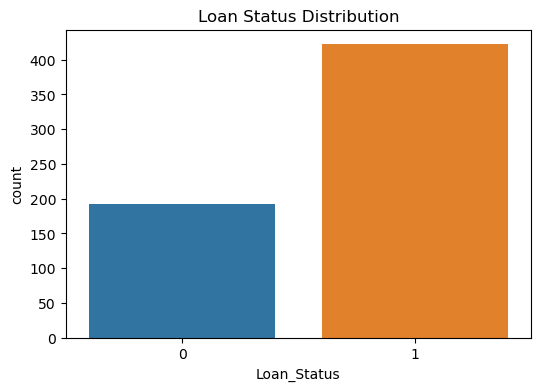

In [6]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x='Loan_Status')

plt.title('Loan Status Distribution')

plt.show()


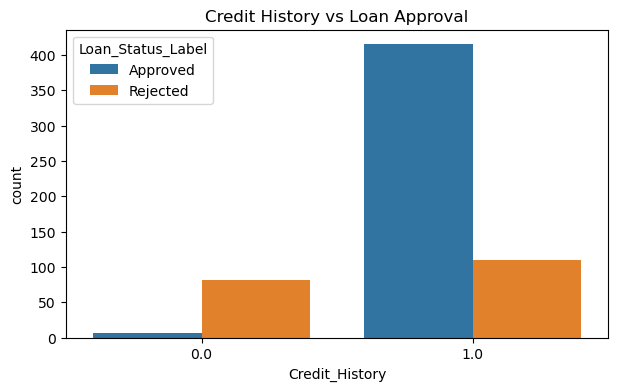

In [7]:
# Convert Loan_Status to string labels for visualization
df['Loan_Status_Label'] = df['Loan_Status'].map({
    1: 'Approved',
    0: 'Rejected'
})

plt.figure(figsize=(7,4))

sns.countplot(
    data=df,
    x='Credit_History',
    hue='Loan_Status_Label'
)

plt.title('Credit History vs Loan Approval')

plt.show()

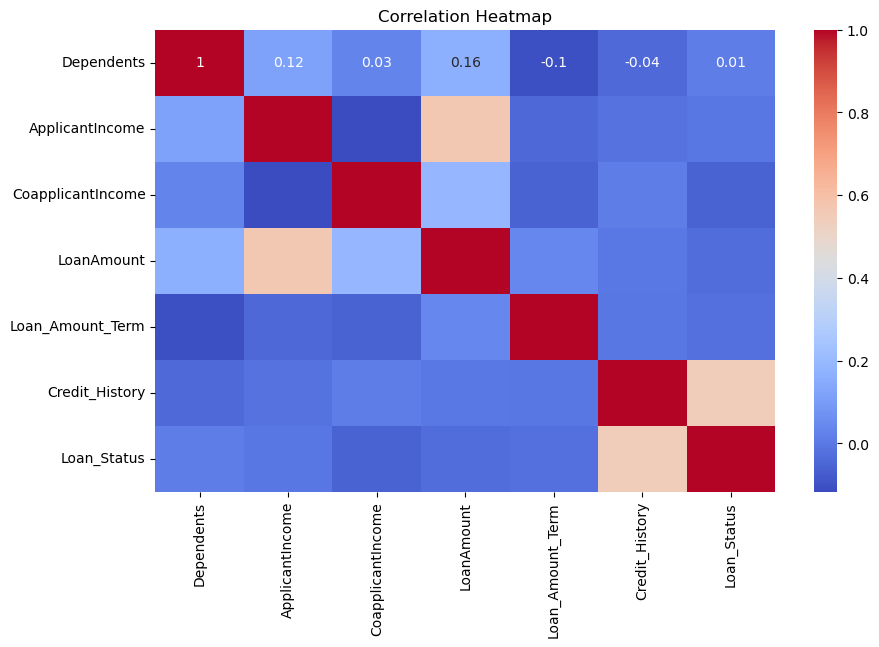

In [8]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap')

plt.show()


## 7. Feature and Target Separation

In [9]:
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']


## 8. Column Transformer

In [10]:
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(exclude=['object']).columns.tolist()

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])


## 9. Train-Test Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


## Logistic Regression

### Theory
Logistic Regression is used for classification and prediction tasks in machine learning.

In [12]:
logistic_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

logistic_pipeline.fit(X_train, y_train)

logistic_pred = logistic_pipeline.predict(X_test)

logistic_acc = accuracy_score(y_test, logistic_pred)
logistic_f1 = f1_score(y_test, logistic_pred)

print('Accuracy:', logistic_acc)
print('F1 Score:', logistic_f1)


Accuracy: 1.0
F1 Score: 1.0


## K-Nearest Neighbors (KNN)

### Theory
K-Nearest Neighbors (KNN) is used for classification and prediction tasks in machine learning.

In [13]:
knn_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', KNeighborsClassifier())
])

knn_pipeline.fit(X_train, y_train)

knn_pred = knn_pipeline.predict(X_test)

knn_acc = accuracy_score(y_test, knn_pred)
knn_f1 = f1_score(y_test, knn_pred)

print('Accuracy:', knn_acc)
print('F1 Score:', knn_f1)


Accuracy: 0.9512195121951219
F1 Score: 0.963855421686747


## Support Vector Machine (SVM)

### Theory
Support Vector Machine (SVM) is used for classification and prediction tasks in machine learning.

In [14]:
svm_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', SVC(probability=True))
])

svm_pipeline.fit(X_train, y_train)

svm_pred = svm_pipeline.predict(X_test)

svm_acc = accuracy_score(y_test, svm_pred)
svm_f1 = f1_score(y_test, svm_pred)

print('Accuracy:', svm_acc)
print('F1 Score:', svm_f1)


Accuracy: 1.0
F1 Score: 1.0


## Decision Tree

### Theory
Decision Tree is used for classification and prediction tasks in machine learning.

In [15]:
dt_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier())
])

dt_pipeline.fit(X_train, y_train)

dt_pred = dt_pipeline.predict(X_test)

dt_acc = accuracy_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred)

print('Accuracy:', dt_acc)
print('F1 Score:', dt_f1)


Accuracy: 1.0
F1 Score: 1.0


## Random Forest

### Theory
Random Forest is used for classification and prediction tasks in machine learning.

In [16]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier())
])

rf_pipeline.fit(X_train, y_train)

rf_pred = rf_pipeline.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print('Accuracy:', rf_acc)
print('F1 Score:', rf_f1)


Accuracy: 1.0
F1 Score: 1.0


## 15. Model Comparison

In [17]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'KNN',
        'SVM',
        'Decision Tree',
        'Random Forest'
    ],
    'Accuracy': [
        logistic_acc,
        knn_acc,
        svm_acc,
        dt_acc,
        rf_acc
    ],
    'F1 Score': [
        logistic_f1,
        knn_f1,
        svm_f1,
        dt_f1,
        rf_f1
    ]
})

print(results)


                 Model  Accuracy  F1 Score
0  Logistic Regression   1.00000  1.000000
1                  KNN   0.95122  0.963855
2                  SVM   1.00000  1.000000
3        Decision Tree   1.00000  1.000000
4        Random Forest   1.00000  1.000000


## 16. Accuracy Comparison Chart

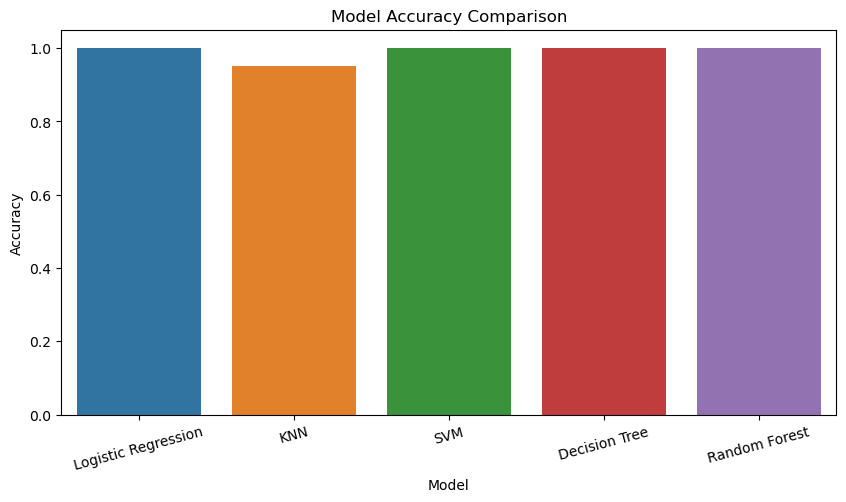

In [18]:
plt.figure(figsize=(10,5))

sns.barplot(data=results, x='Model', y='Accuracy')

plt.title('Model Accuracy Comparison')

plt.xticks(rotation=15)

plt.show()


## 17. F1 Score Comparison Chart

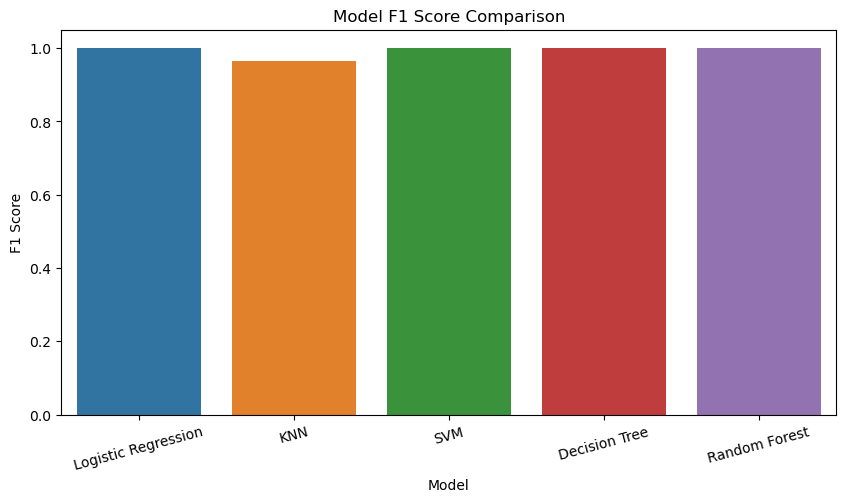

In [19]:
plt.figure(figsize=(10,5))

sns.barplot(data=results, x='Model', y='F1 Score')

plt.title('Model F1 Score Comparison')

plt.xticks(rotation=15)

plt.show()


## 18. Confusion Matrix

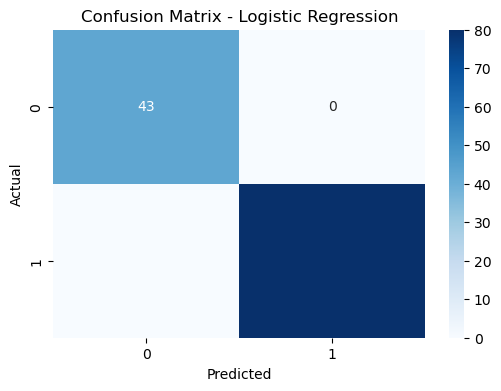

In [20]:
cm = confusion_matrix(y_test, logistic_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('Confusion Matrix - Logistic Regression')

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()


## 19. Classification Report

In [21]:
print(classification_report(y_test, logistic_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        43
           1       1.00      1.00      1.00        80

    accuracy                           1.00       123
   macro avg       1.00      1.00      1.00       123
weighted avg       1.00      1.00      1.00       123



## 20. Save Final Model

In [22]:
joblib.dump(logistic_pipeline, model_path)

print('Model saved successfully!')


Model saved successfully!


## 21. Streamlit Deployment

The final model was deployed using Streamlit to create an interactive web application for loan approval prediction.

## 22. Conclusion and Future Scope

This project successfully implemented multiple machine learning algorithms for loan approval prediction.

Logistic Regression achieved the best overall performance based on Accuracy and F1 Score.

Future improvements can include:
- Hyperparameter tuning
- Cloud deployment
- Real-time database integration
- Explainable AI techniques
- Deep learning models